# Predicting Coral Reef Regimes from Human and Natural Influences
## 1. Project Title
**Notebook 02 — Support Vector Machines (RBF kernel and Polynomial kernel)**

A machine-learning mini-project that predicts which of four **coral reef regimes** a reef site belongs to, using measurements of **human (anthropogenic)** and **natural (biophysical)** influences around the Hawaiian Islands.

The methodology follows the reference project ([Hawaii_RegimesPredictors](https://github.com/salliewalecka/Hawaii_RegimesPredictors), a Stanford CS229 class project built on Jouffray et al. 2019) as a **guide only**. We re-implement and run everything ourselves, so all results here are our own. This notebook uses **exactly the same data preparation** as Notebook 01 so the models can be compared fairly.

> **How to use this notebook:** click **Runtime → Run all**. Every number you see is *calculated by the code in this notebook* from the data — nothing is typed in by hand. All random seeds are fixed, so you will get the same numbers each time you run it.

## 2. Problem Statement

**Task:** *multi-class classification.* For each reef site we know 20 numbers describing human pressures (e.g. fishing, sedimentation, development) and natural conditions (e.g. sea-surface temperature, wave power, depth). We want a model that predicts the site's **reef regime** — one of four classes labelled **1, 2, 3 and 5** in the data.

**Models in this notebook:** *Support Vector Machines* (SVM) with **(A) an RBF kernel** and **(B) a polynomial kernel**, then a head-to-head comparison.

**Main evaluation metric:** **micro-average F1**, the metric emphasized in the reference project. (It is computed on the held-out test set.)

### Three ideas you need before we start

1. **Train / test split.** We hide a part of the data (the *test set*) and only look at it at the very end, to see how the model does on sites it has never seen. The model learns from the *training set* only.
2. **Data leakage.** If *anything* learned from the test data (for example the average used to fill missing values, or the mean used for scaling) sneaks into training, the test score becomes unrealistically good. We prevent this by learning every preprocessing step **only from the training data**.
3. **Pipeline.** A scikit-learn `Pipeline` chains the steps *fill missing values → scale → model* into one object. When we call `.fit()` on training data, every step learns from the training data only; when we later call `.predict()` on the test data, the steps just *apply* what they learned. This is the safest way to avoid leakage.

## 3. Dataset Description
The data come from the reference project's GitHub repository
([salliewalecka/Hawaii_RegimesPredictors](https://github.com/salliewalecka/Hawaii_RegimesPredictors), forked from the original
[JBjouffray/Hawaii_RegimesPredictors](https://github.com/JBjouffray/Hawaii_RegimesPredictors)), which accompanies
*Jouffray et al. (2019), "Parsing human and biophysical drivers of coral reef regimes", Proc. R. Soc. B 286: 20182544*.

**File used:** `Data/Hawaii_RegimesPredictors.txt` — the **raw** file (620 reef sites around the Hawaiian Islands, 39 columns, tab-separated, decimal comma).

> **Why not the `Hawaii_RegimesPredictors_complete.txt` file?** That file already has the missing values filled in, but the reference authors filled them using *all 620 sites before splitting the data* (and used a model that looked at columns that define the regimes). That would leak test-set information into training. We therefore start from the raw file and fill missing values ourselves, *inside the pipeline, using training data only*.

The 39 columns fall into five groups:

| Group | Columns | How we use them |
|---|---|---|
| Identifiers / location | `id_spatial`, `Long`, `Lat`, `Island` | **Not used** (not part of the reference's predictor set) |
| Reef community composition (10) | `Coral`, `CCA`, `Turf`, `Macro`, `Other`, `Grazers`, `Scrapers`, `Browsers`, `Predators`, `Secondary` | **Not used.** The regimes are *defined* from these fish and benthic measurements, so using them to predict the regime would be circular |
| **Anthropogenic predictors (10)** | `Effluent`, `Sedimentation`, `New_Development`, `Habitat_Modification`, `Invasive_Algae`, `Fishing_Comm_Total`, `Fishing_NonComm_Boat_Total`, `Fishing_NonComm_Shore_Line`, `Fishing_NonComm_Shore_Net`, `Fishing_NonComm_Shore_Spear` | **Features** |
| **Biophysical predictors (10)** | `SST_CLIM_M`, `SST_STD`, `CHL_CLIM_M`, `CHL_ANOM_F`, `PAR_CLIM_M`, `PAR_STD`, `WAV_CLIM_M`, `WAV_ANOM_F`, `Complexity`, `Depth` | **Features** |
| Target (5) | `Regime` (values 1, 2, 3, 5) plus `Regime1`, `Regime2`, `Regime3`, `Regime5` (the same label written as 0/1 columns) | **`Regime` is the target.** The four 0/1 columns are *copies of the answer*, so they must never be used as features |

The predictor groupings follow the repository's `Hawaii_PredictorsCategories.txt`. See the paper for the exact definitions of each variable.

## 4. Import Libraries

We import the tools we need and **fix the random seeds** so the results are reproducible.

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay)
from sklearn.svm import SVC

# ---- Reproducibility: fixed random seeds ----
SPLIT_RANDOM_STATE = 47   # same seed the reference project used for its train/test split
RANDOM_STATE = 42         # seed for cross-validation shuffling and for the models
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

print("scikit-learn version:", sklearn.__version__)
print("pandas version      :", pd.__version__)

scikit-learn version: 1.6.1
pandas version      : 2.2.3


## 5. Load Dataset
We read the raw dataset directly from the reference GitHub repository.

* The file is **tab-separated** (`sep="\t"`) and uses a **decimal comma** (`decimal=","`), so we must tell pandas that.
* **If the download fails** (for example, no internet or a firewall), upload `Hawaii_RegimesPredictors.txt` to Colab's file panel (left sidebar → Files → Upload). The code below automatically uses `/content/Hawaii_RegimesPredictors.txt` if it exists. To use Google Drive instead, mount it and change `LOCAL_PATH` to your Drive path, e.g. `/content/drive/MyDrive/Hawaii_RegimesPredictors.txt`.

In [2]:
DATA_URL   = "https://raw.githubusercontent.com/salliewalecka/Hawaii_RegimesPredictors/master/Data/Hawaii_RegimesPredictors.txt"
LOCAL_PATH = "/content/Hawaii_RegimesPredictors.txt"   # used first if you uploaded the file yourself

data_source = LOCAL_PATH if os.path.exists(LOCAL_PATH) else DATA_URL
print("Reading data from:", data_source)

try:
    df = pd.read_csv(data_source, sep="\t", decimal=",")
except Exception as err:
    raise RuntimeError(
        "Could not read the dataset. Please download 'Data/Hawaii_RegimesPredictors.txt' from "
        "https://github.com/salliewalecka/Hawaii_RegimesPredictors and upload it to "
        "/content/Hawaii_RegimesPredictors.txt in Colab (or edit LOCAL_PATH above)."
    ) from err

# Safety checks: make sure we loaded the RAW file we expect (not a different/edited one)
assert df.shape == (620, 39), f"Unexpected shape {df.shape}; expected (620, 39). Is this the right file?"
assert "Regime" in df.columns, "Column 'Regime' not found - wrong file?"
assert df["Complexity"].isna().sum() > 0, "No missing values found - this looks like the '_complete' file, not the raw one."
print("Loaded OK:", df.shape[0], "rows x", df.shape[1], "columns")

Reading data from: https://raw.githubusercontent.com/salliewalecka/Hawaii_RegimesPredictors/master/Data/Hawaii_RegimesPredictors.txt
Loaded OK: 620 rows x 39 columns


## 6. Inspect Dataset

Let's take a first look at the data: its size, column types and first few rows.

In [3]:
print("Shape (rows, columns):", df.shape)
print()
print("Column data types:")
print(df.dtypes.value_counts().to_string())
print()
df.head()

Shape (rows, columns): (620, 39)

Column data types:
float64    30
int64       8
object      1



,id_spatial,Long,Lat,Island,Coral,CCA,Turf,Macro,Other,Grazers,Scrapers,Browsers,Predators,Secondary,Effluent,Sedimentation,New_Development,Habitat_Modification,Invasive_Algae,Fishing_Comm_Total,Fishing_NonComm_Boat_Total,Fishing_NonComm_Shore_Line,Fishing_NonComm_Shore_Net,Fishing_NonComm_Shore_Spear,SST_CLIM_M,SST_STD,CHL_CLIM_M,CHL_ANOM_F,PAR_CLIM_M,PAR_STD,WAV_CLIM_M,WAV_ANOM_F,Complexity,Depth,Regime,Regime1,Regime2,Regime3,Regime5
0,4,-157.307727,21.106717,Molokai,1.023891,1.706485,77.815700,18.088737,1.023891,1.324986,0.153250,0.163843,0.000000,3.393998,0.0,0.075594,0.004250,0,0,0.013817,0.396614,5.622424,3.671531,0.373111,27.474,0.956713,0.1213,0.0237,52.643398,8.5628,36.542160,0.083878,4.889608,2.8000,1,1,0,0,0
1,5,-157.304986,21.113497,Molokai,3.555556,1.333333,83.555556,9.777778,0.888889,0.890407,0.000000,0.248076,0.000000,2.872683,0.0,0.261318,0.004023,0,0,0.013817,0.386873,0.000000,0.000000,0.364839,27.474,0.956713,0.1213,0.0237,52.643398,8.5628,36.542160,0.083878,3.793523,7.3152,1,1,0,0,0
2,6,-157.303306,21.124814,Molokai,17.620555,6.348836,44.875760,25.716525,4.836712,4.628477,0.143309,5.420154,1.347466,2.238995,0.0,0.381684,0.003573,0,0,0.013817,0.377407,0.000000,0.000000,0.309139,27.474,0.956713,0.1154,0.0593,53.954201,9.4296,38.007866,0.084089,5.275938,11.5000,2,0,1,0,0
3,8,-157.299938,21.148297,Molokai,0.675676,1.351351,86.486487,0.337838,5.743243,0.069128,0.000000,0.000000,0.000000,3.341160,0.0,0.135392,0.000406,0,0,0.013817,0.353853,0.000000,0.000000,0.059943,27.474,0.956713,0.1154,0.0593,53.954201,9.4296,39.139775,0.087039,2.511288,29.1000,1,1,0,0,0
4,9,-157.300286,21.128897,Molokai,4.000000,3.111111,53.333333,17.333333,21.777778,11.775000,0.000000,1.655366,0.967914,8.411082,0.0,0.577138,0.003794,0,0,0.013817,0.369782,0.000000,0.000000,0.342674,27.474,0.956713,0.1154,0.0593,53.954201,9.4296,40.587803,0.084932,6.865359,10.0584,2,0,1,0,0


## 7. Preprocessing

Preprocessing has four parts, covered in sections 7–10: choosing the **target and features** (this section), **missing values** (8), **encoding** (9) and **scaling** (10). Everything that *learns* from data is fitted on the training set only (inside a pipeline).


* **Target (`y`)** — the column we want to predict: `Regime`.
* **Features (`X`)** — the 20 anthropogenic + biophysical predictor columns.
* **Everything else is deliberately left out** (see the table in section 3). In particular `Regime1`, `Regime2`, `Regime3`, `Regime5` are just the answer rewritten as 0/1, and the 10 community-composition columns are what the regimes are *made from* — using either would be cheating.

We build the feature list by **column name** (not by position) so the code cannot silently pick the wrong columns.

In [4]:
FEATURES = [
    # --- Anthropogenic (human) predictors ---
    "Effluent", "Sedimentation", "New_Development", "Habitat_Modification", "Invasive_Algae",
    "Fishing_Comm_Total", "Fishing_NonComm_Boat_Total", "Fishing_NonComm_Shore_Line",
    "Fishing_NonComm_Shore_Net", "Fishing_NonComm_Shore_Spear",
    # --- Biophysical (natural) predictors ---
    "SST_CLIM_M", "SST_STD", "CHL_CLIM_M", "CHL_ANOM_F", "PAR_CLIM_M", "PAR_STD",
    "WAV_CLIM_M", "WAV_ANOM_F", "Complexity", "Depth",
]

TARGET = "Regime"

ANTHROPOGENIC = FEATURES[:10]    # human influences
BIOPHYSICAL   = FEATURES[10:]    # natural influences

# Safety checks
assert all(c in df.columns for c in FEATURES), "A feature name is missing from the data"
assert TARGET not in FEATURES
assert not any(c.startswith("Regime") for c in FEATURES), "A target column leaked into the features!"

X = df[FEATURES].copy()
y = df[TARGET].copy()

class_labels = sorted(y.unique().tolist())
class_names  = [f"Regime {c}" for c in class_labels]

print("Number of samples (reef sites):", X.shape[0])
print("Number of features            :", X.shape[1],
      f"({len(ANTHROPOGENIC)} anthropogenic + {len(BIOPHYSICAL)} biophysical)")
print("Target classes                :", class_labels)
print()
class_counts = y.value_counts().sort_index()
pd.DataFrame({"sites": class_counts, "percent": (100 * class_counts / len(y)).round(1)})

Number of samples (reef sites): 620
Number of features            : 20 (10 anthropogenic + 10 biophysical)
Target classes                : [1, 2, 3, 5]



,sites,percent
Regime,,
1,171,27.6
2,172,27.7
3,143,23.1
5,134,21.6


In [5]:
# Summary statistics of the 20 predictor columns (we only LOOK here; nothing is learned or changed)
df[FEATURES].describe().T[["count", "mean", "std", "min", "50%", "max"]]

,count,mean,std,min,50%,max
Effluent,620.0,3827.363948,8556.137170,0.000000,481.001648,88142.132810
Sedimentation,620.0,6.905912,18.743726,0.000000,0.000555,171.111557
New_Development,620.0,0.025509,0.040390,0.000000,0.005849,0.376183
Habitat_Modification,620.0,0.083871,0.277418,0.000000,0.000000,1.000000
Invasive_Algae,620.0,0.212903,0.409690,0.000000,0.000000,1.000000
Fishing_Comm_Total,620.0,0.229942,0.435801,0.000000,0.066593,2.060731
Fishing_NonComm_Boat_Total,620.0,0.526341,0.747922,0.000000,0.301010,3.109559
Fishing_NonComm_Shore_Line,620.0,6.365645,9.469403,0.000000,0.000000,29.123327
Fishing_NonComm_Shore_Net,620.0,0.948522,1.465142,0.000000,0.000000,5.428471
Fishing_NonComm_Shore_Spear,620.0,2.370396,2.601515,0.000000,1.794678,7.422137


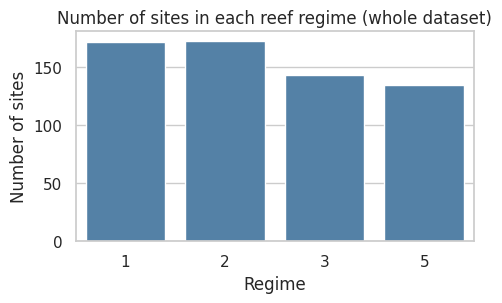

In [6]:
plt.figure(figsize=(5, 3.2))
sns.countplot(x=y, order=class_labels, color="steelblue")
plt.title("Number of sites in each reef regime (whole dataset)")
plt.xlabel("Regime"); plt.ylabel("Number of sites")
plt.tight_layout(); plt.show()

## 8. Missing Value Handling
First, let's see **which predictors have missing values and how many** (this only *counts* — nothing is learned from the data yet).

In [7]:
missing = X.isna().sum()
missing = missing[missing > 0]
pd.DataFrame({"missing values": missing, "percent of sites": (100 * missing / len(X)).round(1)})

,missing values,percent of sites
Complexity,113,18.2
Depth,12,1.9


Only `Complexity` and `Depth` have missing values. How did the reference project deal with them?

| Reference approach | What it did | Problem for us |
|---|---|---|
| `Baseline_Logistic_Model.ipynb` | Dropped rows with missing values, **or** filled with the **mean of the training data** | The mean-fill is fine and leak-free |
| `NA_estimation.ipynb` → `..._complete.txt` | `Depth`: filled with the **median**. `Complexity`: predicted with a **Lasso regression** trained on *all 620 sites*, using many other columns (including the community-composition columns that define the regimes) | Done **before** the train/test split, so test sites influenced the filled-in values (**data leakage**) |

**Our choice:** fill missing values with the **median of the training data**, using `SimpleImputer(strategy="median")` *inside the pipeline*.

* The median is a simple, robust choice (extreme values affect it less than the mean).
* Being inside the pipeline, the median is computed from **training rows only** (and, during cross-validation, from the training part of each fold only) and then re-used for the test rows.
* Honest caveat: about a fifth of the sites have no `Complexity` value, so a constant fill weakens that variable. This is a limitation we mention in the conclusion.

Below we only *define* the imputer (a recipe). It is **not fitted yet** — fitting happens after the split.

In [8]:
imputer = SimpleImputer(strategy="median")   # a recipe only - nothing has been learned yet
imputer

SimpleImputer(strategy='median')

## 9. Encoding
Machine-learning models need numbers. Let's check whether any predictor is text (a *categorical* variable) that would need encoding, e.g. with one-hot encoding.

In [9]:
non_numeric = X.select_dtypes(exclude="number").columns.tolist()
print("Non-numeric predictor columns:", non_numeric)
print()
# Two predictors are yes/no flags. Check how they are stored:
for col in ["Habitat_Modification", "Invasive_Algae"]:
    print(f"{col:22s} unique values: {sorted(X[col].unique().tolist())}")

Non-numeric predictor columns: []

Habitat_Modification   unique values: [0, 1]
Invasive_Algae         unique values: [0, 1]


**Result: no encoding is necessary.**

* All 20 predictors are already numeric.
* `Habitat_Modification` and `Invasive_Algae` are yes/no flags already stored as `0`/`1`. A binary flag *is* its own one-hot encoding (one-hot encoding would only add a redundant second column).
* `Island` (the only text column in the data) is **not** a predictor in the reference work, so we leave it out.
* The target `Regime` is already stored as numbers (1, 2, 3, 5); scikit-learn accepts these directly as class labels.

The reference project also treated those two flags as ordinary numbers and standardized all 20 columns together; we do the same so the two approaches are comparable.

## 10. Feature Scaling
**Standardization** rewrites each feature so that, *in the training data*, it has mean 0 and standard deviation 1: `z = (x − mean) / std`.

Let's look at how different the feature ranges are:


**Is scaling necessary for an SVM? Absolutely — it is critical.** Look at the table: `Effluent` spans tens of thousands while some flags span only 0 to 1.

* An SVM works with **distances / dot-products between sites**. If one feature has a huge numeric range, it will completely **dominate** the distance and the other 19 features become almost invisible.
* Both the RBF kernel (based on the distance between sites) and the polynomial kernel (based on dot-products, raised to a power — which amplifies large values even more) are affected.
* The mean and standard deviation must be learned **from training data only**, then applied to the test data. The pipeline does this automatically.

In [10]:
# We only LOOK at the ranges to see why scaling matters; nothing is fitted here.
ranges = X.agg(["min", "max"]).T
ranges["range"] = ranges["max"] - ranges["min"]
ranges.sort_values("range", ascending=False).round(3)

,min,max,range
Effluent,0.000,88142.133,88142.133
Sedimentation,0.000,171.112,171.112
WAV_CLIM_M,0.887,114.938,114.052
Complexity,0.000,35.868,35.868
Depth,0.488,30.000,29.512
Fishing_NonComm_Shore_Line,0.000,29.123,29.123
PAR_CLIM_M,36.232,56.417,20.185
Fishing_NonComm_Shore_Spear,0.000,7.422,7.422
Fishing_NonComm_Shore_Net,0.000,5.428,5.428
PAR_STD,6.825,11.714,4.890


In [11]:
scaler = StandardScaler()   # a recipe only - the mean/std are learned later, from training data only
scaler

# Our complete preprocessing recipe (still unfitted): impute, then scale
preprocessing = Pipeline([("imputer", imputer), ("scaler", scaler)])
preprocessing

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

## 11. Train/Test Split
We split the 620 sites into:

* **Training set (80%)** — the only data the model and the preprocessing steps learn from. We also run cross-validation *inside* this set to choose settings.
* **Test set (20%)** — locked away until the final evaluation.

We use the **same split as the reference project** (`test_size=0.2`, `random_state=47`). The reference additionally cut a validation set out of the training data and then merged it back for 5-fold cross-validation; our 5-fold cross-validation on the training set plays exactly the same role, so no separate validation set is needed.

> The reference split is *random* but **not stratified**, so the test set can have class proportions different from the whole dataset (we print them below). To use a stratified split instead, set `STRATIFY_SPLIT = True` — **but if you do, make sure your teammate does the same** so that all models are compared on identical test sites.

In [12]:
STRATIFY_SPLIT = False   # False = identical to the reference project's split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SPLIT_RANDOM_STATE,
    stratify=y if STRATIFY_SPLIT else None,
)

print("Total sites   :", len(X))
print("Training sites:", len(X_train), f"({100*len(X_train)/len(X):.0f}%)")
print("Test sites    :", len(X_test),  f"({100*len(X_test)/len(X):.0f}%)")
print("Number of features:", X_train.shape[1])
print("Target classes    :", class_labels)
print()
print("Class distribution (number of sites):")
pd.DataFrame({
    "whole dataset": y.value_counts().sort_index(),
    "train": y_train.value_counts().sort_index(),
    "test": y_test.value_counts().sort_index(),
})

Total sites   : 620
Training sites: 496 (80%)
Test sites    : 124 (20%)
Number of features: 20
Target classes    : [1, 2, 3, 5]

Class distribution (number of sites):


,whole dataset,train,test
Regime,,,
1,171,127,44
2,172,135,37
3,143,118,25
5,134,116,18


In [13]:
# Missing values per set (they are still there - they will be filled inside the pipeline)
print("Missing values in TRAIN:", X_train.isna().sum()[lambda s: s > 0].to_dict())
print("Missing values in TEST :", X_test.isna().sum()[lambda s: s > 0].to_dict())

# What will the imputer learn? ONLY these medians, computed from the training rows:
demo_imputer = clone(imputer).fit(X_train)
print()
print("Median used to fill missing values (learned from TRAINING data only):")
print(pd.Series(demo_imputer.statistics_, index=FEATURES)[["Complexity", "Depth"]].round(3).to_string())

Missing values in TRAIN: {'Complexity': 90, 'Depth': 9}
Missing values in TEST : {'Complexity': 23, 'Depth': 3}

Median used to fill missing values (learned from TRAINING data only):
Complexity    9.672
Depth         8.992


### Data-leakage checklist (what this notebook does)

- ✅ The test set is split off **before** any preprocessing is fitted.
- ✅ Imputation (median) and scaling (mean/std) are **inside the `Pipeline`**, so they are fitted on training data only.
- ✅ Hyper-parameter tuning uses **cross-validation inside the training set**; the test set is never used to choose settings.
- ✅ The test set is used **once**, for the final evaluation.
- ✅ The target and its copies (`Regime1/2/3/5`) and the community-composition columns that define the regimes are **not** features.
- ✅ We start from the **raw** data file, not the reference's pre-imputed `_complete` file.

In [14]:
# Shared by both SVMs: the same 5-fold cross-validation (shuffled, fixed seed, class proportions kept)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}   # we collect final numbers here for the comparison in section 34

## 12. SVM — RBF Kernel

**Idea.** An SVM finds the boundary that separates classes with the **widest possible margin**. A *kernel* lets it draw **curved** boundaries. The **RBF (Gaussian) kernel** measures similarity between two sites as `exp(−γ · distance²)`: sites that are close together are very similar, far apart sites are not.

For more than two classes, scikit-learn's `SVC` trains one SVM for every *pair* of regimes ("one-vs-one") and lets them vote.

**Settings we tune** (with cross-validation on the training set only):

| Setting | Meaning | Values tried |
|---|---|---|
| `C` | How strongly mistakes on the training data are punished. **Small C** = smoother, simpler boundary; **large C** = tries hard to fit every training site (risk of overfitting). | 0.1, 1, 10, 100, 1000 |
| `gamma` | How far one training site's influence reaches. **Small gamma** = far reach, smooth boundary; **large gamma** = very local, wiggly boundary (risk of overfitting). | 0.001, 0.005, 0.01, 0.05, 0.1, 0.5 |

`SVC` does not need `max_iter` here (the default runs until it converges), and we do not request probabilities (`probability=True` is slow and not needed for the metrics). We fix `random_state` for reproducibility.

**Reference point.** The reference notebooks fit `SVC(kernel='rbf')` with **default settings and no tuning**. We measure that too (cross-validation on the training set), so we can see whether tuning helps.

In [15]:
rbf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("model",   SVC(kernel="rbf", random_state=RANDOM_STATE)),
])

rbf_param_grid = {
    "model__C":     [0.1, 1, 10, 100, 1000],
    "model__gamma": [0.001, 0.005, 0.01, 0.05, 0.1, 0.5],
}

rbf_search = GridSearchCV(rbf_pipeline, rbf_param_grid, scoring="f1_micro", cv=cv,
                          return_train_score=True, n_jobs=1)

# Reference point: default SVC (C=1, gamma='scale'), no tuning - CV on the training set only
rbf_default_cv = cross_val_score(rbf_pipeline, X_train, y_train, cv=cv, scoring="f1_micro")
print(f"CV micro-F1 of the DEFAULT RBF SVM (no tuning): {rbf_default_cv.mean():.3f}  (+/- {rbf_default_cv.std():.3f})")
rbf_pipeline

CV micro-F1 of the DEFAULT RBF SVM (no tuning): 0.647  (+/- 0.015)


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()), ('model', SVC(random_state=42))])

## 13. Train RBF Model

`.fit()` tries all 5 × 6 = 30 combinations with 5-fold cross-validation (150 fits), then re-trains the best combination on the whole training set.

Warnings raised during the search: 0
Best settings (chosen by cross-validation): {'model__C': 10, 'model__gamma': 0.05}
Best CV micro-F1 (tuned)          : 0.679
CV micro-F1 (default, from above) : 0.647


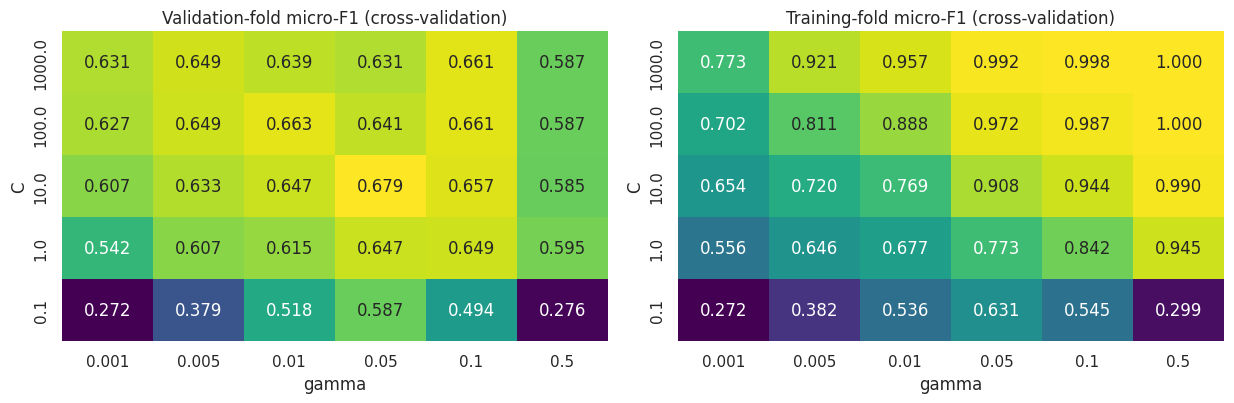

In [16]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    rbf_search.fit(X_train, y_train)         # <-- only TRAINING data is used here
print("Warnings raised during the search:", len(caught))

print("Best settings (chosen by cross-validation):", rbf_search.best_params_)
print(f"Best CV micro-F1 (tuned)          : {rbf_search.best_score_:.3f}")
print(f"CV micro-F1 (default, from above) : {rbf_default_cv.mean():.3f}")

rbf_cv_df = pd.DataFrame(rbf_search.cv_results_)
rbf_cv_df["C"]     = rbf_cv_df["param_model__C"].astype(float)
rbf_cv_df["gamma"] = rbf_cv_df["param_model__gamma"].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
sns.heatmap(rbf_cv_df.pivot(index="C", columns="gamma", values="mean_test_score"), annot=True, fmt=".3f",
            cmap="viridis", ax=axes[0], cbar=False)
axes[0].set_title("Validation-fold micro-F1 (cross-validation)")
sns.heatmap(rbf_cv_df.pivot(index="C", columns="gamma", values="mean_train_score"), annot=True, fmt=".3f",
            cmap="viridis", ax=axes[1], cbar=False)
axes[1].set_title("Training-fold micro-F1 (cross-validation)")
for ax in axes: ax.invert_yaxis()
plt.tight_layout(); plt.show()

**How to read these heatmaps.** The left map is the one we use to *choose* settings (scores on data the model did not train on in each fold). The right map shows the scores on the data it *did* train on. Where the right map is much brighter than the left (large `C` and/or large `gamma`), the model is **memorizing** the training sites — overfitting.

**Integrity check:** the pipeline's imputer and scaler must have learned from the training rows only.

In [17]:
rbf_best = rbf_search.best_estimator_          # preprocessing + tuned SVM, re-trained on all training data
rbf_svm  = rbf_best.named_steps["model"]

train_medians = X_train.median()
assert np.allclose(rbf_best.named_steps["imputer"].statistics_, train_medians.values), "Imputer not fitted on training data only!"
assert np.allclose(rbf_best.named_steps["scaler"].mean_, X_train.fillna(train_medians).mean().values), "Scaler not fitted on training data only!"
print("Leakage check passed: imputer and scaler were fitted on the training rows only.")
print("Support vectors per class:", dict(zip(rbf_svm.classes_.tolist(), rbf_svm.n_support_.tolist())),
      f"(total {rbf_svm.n_support_.sum()} of {len(X_train)} training sites)")

Leakage check passed: imputer and scaler were fitted on the training rows only.
Support vectors per class: {1: 100, 2: 95, 3: 99, 5: 98} (total 392 of 496 training sites)


## 14. Predictions (RBF)

We predict the regime for **both** the training sites and the test sites. The fitted search object applies the whole pipeline (impute → scale → SVM) automatically.

In [18]:
rbf_train_pred = rbf_search.predict(X_train)
rbf_test_pred  = rbf_search.predict(X_test)

pd.DataFrame({"true regime": y_test.iloc[:8].values, "RBF prediction": rbf_test_pred[:8]}, index=X_test.index[:8])

,true regime,RBF prediction
361,5,5
217,1,1
506,1,1
255,1,3
593,1,1
557,1,1
530,1,1
331,3,5


## 15. Evaluation (RBF)

**Training performance vs. test performance — an important difference**

* **Training** scores tell us how well the model fits sites it *has already seen*. They are usually too optimistic.
* **Test** scores tell us how well it works on *new* sites. **Only the test score is the honest measure of performance.**
* A big gap (training much higher than test) is a sign of **overfitting**.

Below, every table labels clearly which numbers are TRAIN and which are TEST. We also report the **cross-validation (CV)** score from the training set, which is the score that was used to choose the settings.

## 16. Accuracy — SVM RBF

**Accuracy** = (number of correct predictions) ÷ (total number of predictions). Easy to understand, but it can be misleading when classes are very unequal in size (here they are fairly similar).

In [19]:
rbf_acc_train = accuracy_score(y_train, rbf_train_pred)
rbf_acc_test  = accuracy_score(y_test,  rbf_test_pred)

print("SVM RBF - ACCURACY")
print(f"  TRAIN (optimistic)       : {rbf_acc_train:.3f}")
print(f"  CV on train (selection)  : {rbf_search.best_score_:.3f}   (5-fold CV micro-F1, which equals accuracy)")
print(f"  TEST  (honest estimate)  : {rbf_acc_test:.3f}")
print(f"  Test sites misclassified : {int((y_test.to_numpy() != rbf_test_pred).sum())} out of {len(y_test)}")

SVM RBF - ACCURACY
  TRAIN (optimistic)       : 0.903
  CV on train (selection)  : 0.679   (5-fold CV micro-F1, which equals accuracy)
  TEST  (honest estimate)  : 0.661
  Test sites misclassified : 42 out of 124


## 17. Precision — SVM RBF

**Precision** (for one regime) answers: *"When the model says Regime k, how often is it right?"* = true positives ÷ (true positives + false positives).

With 4 classes we need to *average* the four per-class precisions:
* **macro** average = simple mean of the 4 values (every regime counts equally),
* **weighted** average = mean weighted by how many sites each regime has.

In [20]:
rbf_prec_train_macro = precision_score(y_train, rbf_train_pred, average="macro",    zero_division=0)
rbf_prec_train_wtd   = precision_score(y_train, rbf_train_pred, average="weighted", zero_division=0)
rbf_prec_test_macro  = precision_score(y_test,  rbf_test_pred,  average="macro",    zero_division=0)
rbf_prec_test_wtd    = precision_score(y_test,  rbf_test_pred,  average="weighted", zero_division=0)

print("SVM RBF - PRECISION")
print(pd.DataFrame({"macro": [rbf_prec_train_macro, rbf_prec_test_macro],
                    "weighted": [rbf_prec_train_wtd, rbf_prec_test_wtd]},
                   index=["TRAIN (optimistic)", "TEST (honest)"]).round(3).to_string())

SVM RBF - PRECISION
                    macro  weighted
TRAIN (optimistic)  0.904     0.906
TEST (honest)       0.643     0.669


## 18. Recall — SVM RBF

**Recall** (for one regime) answers: *"Of all the sites that truly are Regime k, how many did the model find?"* = true positives ÷ (true positives + false negatives).

In [21]:
rbf_rec_train_macro = recall_score(y_train, rbf_train_pred, average="macro",    zero_division=0)
rbf_rec_train_wtd   = recall_score(y_train, rbf_train_pred, average="weighted", zero_division=0)
rbf_rec_test_macro  = recall_score(y_test,  rbf_test_pred,  average="macro",    zero_division=0)
rbf_rec_test_wtd    = recall_score(y_test,  rbf_test_pred,  average="weighted", zero_division=0)

print("SVM RBF - RECALL")
print(pd.DataFrame({"macro": [rbf_rec_train_macro, rbf_rec_test_macro],
                    "weighted": [rbf_rec_train_wtd, rbf_rec_test_wtd]},
                   index=["TRAIN (optimistic)", "TEST (honest)"]).round(3).to_string())

SVM RBF - RECALL
                    macro  weighted
TRAIN (optimistic)  0.903     0.903
TEST (honest)       0.658     0.661


## 19. F1 Score — SVM RBF

**F1** combines precision and recall into one number (their harmonic mean), so a model only gets a high F1 if *both* are high: `F1 = 2 · precision · recall / (precision + recall)`. Again we show the macro and weighted averages over the four regimes.

In [22]:
rbf_f1_train_macro = f1_score(y_train, rbf_train_pred, average="macro",    zero_division=0)
rbf_f1_train_wtd   = f1_score(y_train, rbf_train_pred, average="weighted", zero_division=0)
rbf_f1_test_macro  = f1_score(y_test,  rbf_test_pred,  average="macro",    zero_division=0)
rbf_f1_test_wtd    = f1_score(y_test,  rbf_test_pred,  average="weighted", zero_division=0)

print("SVM RBF - F1 SCORE")
print(pd.DataFrame({"macro": [rbf_f1_train_macro, rbf_f1_test_macro],
                    "weighted": [rbf_f1_train_wtd, rbf_f1_test_wtd]},
                   index=["TRAIN (optimistic)", "TEST (honest)"]).round(3).to_string())

SVM RBF - F1 SCORE
                    macro  weighted
TRAIN (optimistic)  0.903     0.904
TEST (honest)       0.648     0.663


## 20. Micro-average F1 — SVM RBF  ⭐ (main metric)

**Micro-average F1** pools *all* individual predictions together (all sites, all classes) and computes one precision, one recall and one F1 from the pooled counts.

For a problem where every site has exactly **one** true class and gets exactly **one** predicted class (like ours), micro-precision = micro-recall = micro-F1 = **accuracy**. We verify this below instead of just claiming it.

> **Note on the reference code:** the reference's helper `microaveage_F1()` actually returns the *weighted* average F1 (from the `weighted avg` row of the classification report), not the micro average. In this notebook the micro-average F1 is computed with `average="micro"`, and the weighted F1 is shown separately above.

Because the test set is small, the score has noticeable uncertainty. We estimate it with the standard error of a proportion: `sqrt(p · (1−p) / n)`.

In [23]:
rbf_micro_train = f1_score(y_train, rbf_train_pred, average="micro")
rbf_micro_test  = f1_score(y_test,  rbf_test_pred,  average="micro")
rbf_micro_cv    = rbf_search.best_score_    # the CV score used to choose settings (scoring="f1_micro")

# Check the claim "micro-precision = micro-recall = micro-F1 = accuracy"
mp = precision_score(y_test, rbf_test_pred, average="micro")
mr = recall_score(y_test,    rbf_test_pred, average="micro")
print("Check on TEST: micro-precision, micro-recall, micro-F1, accuracy =",
      round(mp, 4), round(mr, 4), round(rbf_micro_test, 4), round(rbf_acc_test, 4))
assert np.isclose(mp, rbf_micro_test) and np.isclose(mr, rbf_micro_test) and np.isclose(rbf_micro_test, rbf_acc_test)

se = np.sqrt(rbf_micro_test * (1 - rbf_micro_test) / len(y_test))
print()
print("SVM RBF - MICRO-AVERAGE F1")
print(f"  TRAIN (optimistic)       : {rbf_micro_train:.3f}")
print(f"  CV on train (selection)  : {rbf_micro_cv:.3f}")
print(f"  TEST  (honest estimate)  : {rbf_micro_test:.3f}   (approx. standard error +/- {se:.3f}, n = {len(y_test)} test sites)")
print(f"  Weighted F1 on TEST (what the reference helper function calls 'micro'): {rbf_f1_test_wtd:.3f}")

Check on TEST: micro-precision, micro-recall, micro-F1, accuracy = 0.6613 0.6613 0.6613 0.6613

SVM RBF - MICRO-AVERAGE F1
  TRAIN (optimistic)       : 0.903
  CV on train (selection)  : 0.679
  TEST  (honest estimate)  : 0.661   (approx. standard error +/- 0.043, n = 124 test sites)
  Weighted F1 on TEST (what the reference helper function calls 'micro'): 0.663


## 21. Confusion Matrix — SVM RBF

A **confusion matrix** shows, for each *true* regime (rows), which regime the model *predicted* (columns). Numbers on the diagonal are correct predictions; everything off the diagonal is a mistake — and it shows *which* regimes get confused with each other.

* Left: **TRAIN** (counts) &nbsp;|&nbsp; Middle: **TEST** (counts) &nbsp;|&nbsp; Right: **TEST** as a fraction of each true regime (the diagonal is that regime's recall).

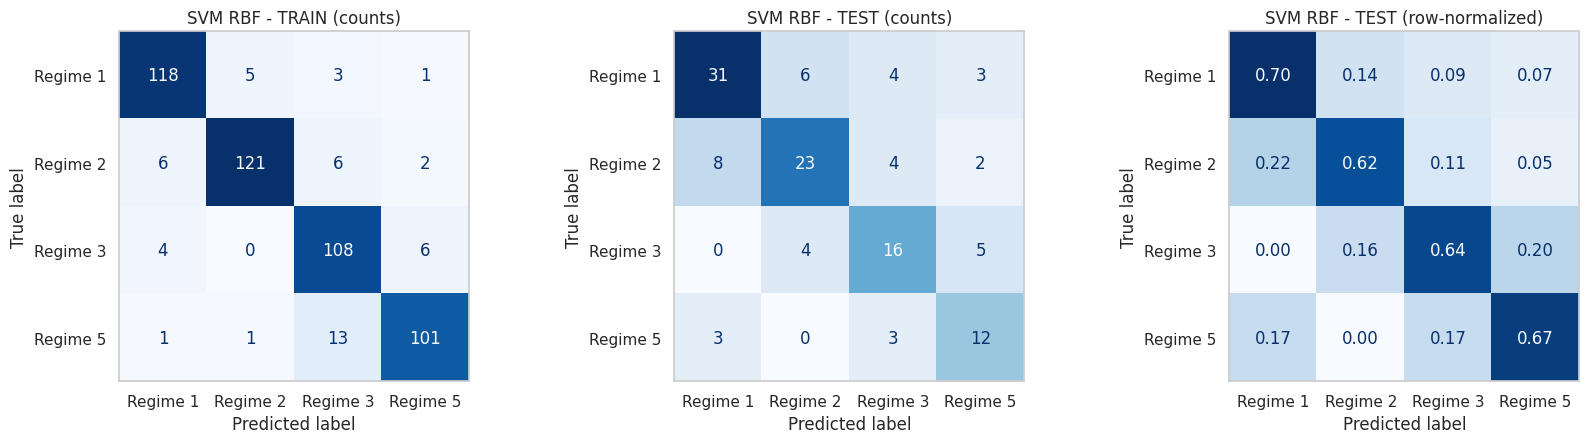

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

ConfusionMatrixDisplay.from_predictions(y_train, rbf_train_pred, labels=class_labels, display_labels=class_names,
                                        cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("SVM RBF - TRAIN (counts)")

ConfusionMatrixDisplay.from_predictions(y_test, rbf_test_pred, labels=class_labels, display_labels=class_names,
                                        cmap="Blues", ax=axes[1], colorbar=False)
axes[1].set_title("SVM RBF - TEST (counts)")

ConfusionMatrixDisplay.from_predictions(y_test, rbf_test_pred, labels=class_labels, display_labels=class_names,
                                        normalize="true", values_format=".2f", cmap="Blues", ax=axes[2], colorbar=False)
axes[2].set_title("SVM RBF - TEST (row-normalized)")

for ax in axes:
    ax.grid(False)
plt.tight_layout(); plt.show()

## 22. Classification Report — SVM RBF

The classification report lists precision, recall and F1 **for each regime separately**, plus the averages. `support` is the number of real sites of that regime in the data being evaluated.

In [25]:
print("=" * 70)
print("SVM RBF - classification report on the TRAINING set (optimistic)")
print("=" * 70)
print(classification_report(y_train, rbf_train_pred, labels=class_labels, target_names=class_names, digits=3, zero_division=0))

print("=" * 70)
print("SVM RBF - classification report on the TEST set (honest estimate)")
print("=" * 70)
print(classification_report(y_test, rbf_test_pred, labels=class_labels, target_names=class_names, digits=3, zero_division=0))

# Keep the numbers for the final summary
results["SVM RBF"] = {
    "Micro-F1 (= accuracy) TRAIN": rbf_micro_train,
    "Micro-F1 CV (5-fold, train)": rbf_micro_cv,
    "Micro-F1 TEST": rbf_micro_test,
    "Macro precision TEST": rbf_prec_test_macro,
    "Macro recall TEST": rbf_rec_test_macro,
    "Macro F1 TEST": rbf_f1_test_macro,
    "Weighted F1 TEST": rbf_f1_test_wtd,
}

SVM RBF - classification report on the TRAINING set (optimistic)
              precision    recall  f1-score   support

    Regime 1      0.915     0.929     0.922       127
    Regime 2      0.953     0.896     0.924       135
    Regime 3      0.831     0.915     0.871       118
    Regime 5      0.918     0.871     0.894       116

    accuracy                          0.903       496
   macro avg      0.904     0.903     0.903       496
weighted avg      0.906     0.903     0.904       496

SVM RBF - classification report on the TEST set (honest estimate)
              precision    recall  f1-score   support

    Regime 1      0.738     0.705     0.721        44
    Regime 2      0.697     0.622     0.657        37
    Regime 3      0.593     0.640     0.615        25
    Regime 5      0.545     0.667     0.600        18

    accuracy                          0.661       124
   macro avg      0.643     0.658     0.648       124
weighted avg      0.669     0.661     0.663       124


## 23. SVM — Polynomial Kernel

**Idea.** The **polynomial kernel** measures similarity as `(γ · x·z + r)^d`, where `x·z` is the dot-product of two sites. It lets the SVM use *combinations* of features (interactions) up to degree `d`. A low degree gives gently curved boundaries; a high degree gives very flexible, wiggly ones.

**Settings we tune** (cross-validation on the training set only):

| Setting | Meaning | Values tried |
|---|---|---|
| `C` | Penalty for mistakes (small = smoother, large = tighter fit) | 0.1, 1, 10, 100 |
| `degree` (*d*) | Highest power of the polynomial | 2, 3, 4 |
| `gamma` (*γ*) | Scales the dot-product | 0.01, 0.05, 0.1 |
| `coef0` (*r*) | Constant added before the power: 0 uses only terms of exactly degree *d*; 1 also mixes in lower-degree terms | 0, 1 |

4 × 3 × 3 × 2 = 72 combinations × 5 folds = 360 fits. As with the RBF model, we also measure the **default** `SVC(kernel="poly")` (what the reference used) as a reference point.

In [26]:
poly_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("model",   SVC(kernel="poly", random_state=RANDOM_STATE)),
])

poly_param_grid = {
    "model__C":      [0.1, 1, 10, 100],
    "model__degree": [2, 3, 4],
    "model__gamma":  [0.01, 0.05, 0.1],
    "model__coef0":  [0, 1],
}

poly_search = GridSearchCV(poly_pipeline, poly_param_grid, scoring="f1_micro", cv=cv,
                           return_train_score=True, n_jobs=1)

# Reference point: default polynomial SVC (C=1, degree=3, gamma='scale', coef0=0) - CV on the training set only
poly_default_cv = cross_val_score(poly_pipeline, X_train, y_train, cv=cv, scoring="f1_micro")
print(f"CV micro-F1 of the DEFAULT polynomial SVM (no tuning): {poly_default_cv.mean():.3f}  (+/- {poly_default_cv.std():.3f})")
poly_pipeline

CV micro-F1 of the DEFAULT polynomial SVM (no tuning): 0.637  (+/- 0.021)


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model', SVC(kernel='poly', random_state=42))])

## 24. Train Polynomial Model

In [27]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    poly_search.fit(X_train, y_train)        # <-- only TRAINING data is used here
print("Warnings raised during the search:", len(caught))

print("Best settings (chosen by cross-validation):", poly_search.best_params_)
print(f"Best CV micro-F1 (tuned)          : {poly_search.best_score_:.3f}")
print(f"CV micro-F1 (default, from above) : {poly_default_cv.mean():.3f}")

# The 4-setting grid is hard to draw, so show the 8 best combinations as a table
poly_cv_df = pd.DataFrame(poly_search.cv_results_)
cols = ["param_model__C", "param_model__degree", "param_model__gamma", "param_model__coef0",
        "mean_test_score", "mean_train_score", "rank_test_score"]
top = poly_cv_df.sort_values("rank_test_score")[cols].head(8)
top.columns = ["C", "degree", "gamma", "coef0", "CV micro-F1 (validation folds)", "CV micro-F1 (training folds)", "rank"]
top.round(4).reset_index(drop=True)

Warnings raised during the search: 0
Best settings (chosen by cross-validation): {'model__C': 100, 'model__coef0': 1, 'model__degree': 3, 'model__gamma': 0.01}
Best CV micro-F1 (tuned)          : 0.661
CV micro-F1 (default, from above) : 0.637


,C,degree,gamma,coef0,CV micro-F1 (validation folds),CV micro-F1 (training folds),rank
0,100.0,3,0.01,1,0.6612,0.9068,1
1,1.0,4,0.05,1,0.6592,0.9037,2
2,0.1,4,0.05,1,0.6572,0.7999,3
3,100.0,2,0.01,1,0.6552,0.8564,4
4,1.0,3,0.10,1,0.6552,0.9199,5
5,1.0,3,0.10,0,0.6531,0.8851,6
6,0.1,4,0.10,1,0.6512,0.8876,7
7,0.1,3,0.05,1,0.6511,0.7354,8


In [28]:
poly_best = poly_search.best_estimator_
poly_svm  = poly_best.named_steps["model"]

assert np.allclose(poly_best.named_steps["imputer"].statistics_, X_train.median().values), "Imputer not fitted on training data only!"
assert np.allclose(poly_best.named_steps["scaler"].mean_, X_train.fillna(X_train.median()).mean().values), "Scaler not fitted on training data only!"
print("Leakage check passed: imputer and scaler were fitted on the training rows only.")
print("Support vectors per class:", dict(zip(poly_svm.classes_.tolist(), poly_svm.n_support_.tolist())),
      f"(total {poly_svm.n_support_.sum()} of {len(X_train)} training sites)")

Leakage check passed: imputer and scaler were fitted on the training rows only.
Support vectors per class: {1: 83, 2: 83, 3: 86, 5: 84} (total 336 of 496 training sites)


## 25. Predictions (Polynomial)

In [29]:
poly_train_pred = poly_search.predict(X_train)
poly_test_pred  = poly_search.predict(X_test)

pd.DataFrame({"true regime": y_test.iloc[:8].values, "Poly prediction": poly_test_pred[:8]}, index=X_test.index[:8])

,true regime,Poly prediction
361,5,5
217,1,1
506,1,1
255,1,3
593,1,1
557,1,1
530,1,2
331,3,5


## 26. Evaluation (Polynomial)

**Training performance vs. test performance — an important difference**

* **Training** scores tell us how well the model fits sites it *has already seen*. They are usually too optimistic.
* **Test** scores tell us how well it works on *new* sites. **Only the test score is the honest measure of performance.**
* A big gap (training much higher than test) is a sign of **overfitting**.

Below, every table labels clearly which numbers are TRAIN and which are TEST. We also report the **cross-validation (CV)** score from the training set, which is the score that was used to choose the settings.

## 27. Accuracy — SVM Polynomial

**Accuracy** = (number of correct predictions) ÷ (total number of predictions). Easy to understand, but it can be misleading when classes are very unequal in size (here they are fairly similar).

In [30]:
poly_acc_train = accuracy_score(y_train, poly_train_pred)
poly_acc_test  = accuracy_score(y_test,  poly_test_pred)

print("SVM Polynomial - ACCURACY")
print(f"  TRAIN (optimistic)       : {poly_acc_train:.3f}")
print(f"  CV on train (selection)  : {poly_search.best_score_:.3f}   (5-fold CV micro-F1, which equals accuracy)")
print(f"  TEST  (honest estimate)  : {poly_acc_test:.3f}")
print(f"  Test sites misclassified : {int((y_test.to_numpy() != poly_test_pred).sum())} out of {len(y_test)}")

SVM Polynomial - ACCURACY
  TRAIN (optimistic)       : 0.897
  CV on train (selection)  : 0.661   (5-fold CV micro-F1, which equals accuracy)
  TEST  (honest estimate)  : 0.645
  Test sites misclassified : 44 out of 124


## 28. Precision — SVM Polynomial

**Precision** (for one regime) answers: *"When the model says Regime k, how often is it right?"* = true positives ÷ (true positives + false positives).

With 4 classes we need to *average* the four per-class precisions:
* **macro** average = simple mean of the 4 values (every regime counts equally),
* **weighted** average = mean weighted by how many sites each regime has.

In [31]:
poly_prec_train_macro = precision_score(y_train, poly_train_pred, average="macro",    zero_division=0)
poly_prec_train_wtd   = precision_score(y_train, poly_train_pred, average="weighted", zero_division=0)
poly_prec_test_macro  = precision_score(y_test,  poly_test_pred,  average="macro",    zero_division=0)
poly_prec_test_wtd    = precision_score(y_test,  poly_test_pred,  average="weighted", zero_division=0)

print("SVM Polynomial - PRECISION")
print(pd.DataFrame({"macro": [poly_prec_train_macro, poly_prec_test_macro],
                    "weighted": [poly_prec_train_wtd, poly_prec_test_wtd]},
                   index=["TRAIN (optimistic)", "TEST (honest)"]).round(3).to_string())

SVM Polynomial - PRECISION
                    macro  weighted
TRAIN (optimistic)  0.897     0.899
TEST (honest)       0.629     0.654


## 29. Recall — SVM Polynomial

**Recall** (for one regime) answers: *"Of all the sites that truly are Regime k, how many did the model find?"* = true positives ÷ (true positives + false negatives).

In [32]:
poly_rec_train_macro = recall_score(y_train, poly_train_pred, average="macro",    zero_division=0)
poly_rec_train_wtd   = recall_score(y_train, poly_train_pred, average="weighted", zero_division=0)
poly_rec_test_macro  = recall_score(y_test,  poly_test_pred,  average="macro",    zero_division=0)
poly_rec_test_wtd    = recall_score(y_test,  poly_test_pred,  average="weighted", zero_division=0)

print("SVM Polynomial - RECALL")
print(pd.DataFrame({"macro": [poly_rec_train_macro, poly_rec_test_macro],
                    "weighted": [poly_rec_train_wtd, poly_rec_test_wtd]},
                   index=["TRAIN (optimistic)", "TEST (honest)"]).round(3).to_string())

SVM Polynomial - RECALL
                    macro  weighted
TRAIN (optimistic)  0.896     0.897
TEST (honest)       0.641     0.645


## 30. F1 Score — SVM Polynomial

**F1** combines precision and recall into one number (their harmonic mean), so a model only gets a high F1 if *both* are high: `F1 = 2 · precision · recall / (precision + recall)`. Again we show the macro and weighted averages over the four regimes.

In [33]:
poly_f1_train_macro = f1_score(y_train, poly_train_pred, average="macro",    zero_division=0)
poly_f1_train_wtd   = f1_score(y_train, poly_train_pred, average="weighted", zero_division=0)
poly_f1_test_macro  = f1_score(y_test,  poly_test_pred,  average="macro",    zero_division=0)
poly_f1_test_wtd    = f1_score(y_test,  poly_test_pred,  average="weighted", zero_division=0)

print("SVM Polynomial - F1 SCORE")
print(pd.DataFrame({"macro": [poly_f1_train_macro, poly_f1_test_macro],
                    "weighted": [poly_f1_train_wtd, poly_f1_test_wtd]},
                   index=["TRAIN (optimistic)", "TEST (honest)"]).round(3).to_string())

SVM Polynomial - F1 SCORE
                    macro  weighted
TRAIN (optimistic)  0.896     0.898
TEST (honest)       0.633     0.647


## 31. Micro-average F1 — SVM Polynomial  ⭐ (main metric)

**Micro-average F1** pools *all* individual predictions together (all sites, all classes) and computes one precision, one recall and one F1 from the pooled counts.

For a problem where every site has exactly **one** true class and gets exactly **one** predicted class (like ours), micro-precision = micro-recall = micro-F1 = **accuracy**. We verify this below instead of just claiming it.

> **Note on the reference code:** the reference's helper `microaveage_F1()` actually returns the *weighted* average F1 (from the `weighted avg` row of the classification report), not the micro average. In this notebook the micro-average F1 is computed with `average="micro"`, and the weighted F1 is shown separately above.

Because the test set is small, the score has noticeable uncertainty. We estimate it with the standard error of a proportion: `sqrt(p · (1−p) / n)`.

In [34]:
poly_micro_train = f1_score(y_train, poly_train_pred, average="micro")
poly_micro_test  = f1_score(y_test,  poly_test_pred,  average="micro")
poly_micro_cv    = poly_search.best_score_    # the CV score used to choose settings (scoring="f1_micro")

# Check the claim "micro-precision = micro-recall = micro-F1 = accuracy"
mp = precision_score(y_test, poly_test_pred, average="micro")
mr = recall_score(y_test,    poly_test_pred, average="micro")
print("Check on TEST: micro-precision, micro-recall, micro-F1, accuracy =",
      round(mp, 4), round(mr, 4), round(poly_micro_test, 4), round(poly_acc_test, 4))
assert np.isclose(mp, poly_micro_test) and np.isclose(mr, poly_micro_test) and np.isclose(poly_micro_test, poly_acc_test)

se = np.sqrt(poly_micro_test * (1 - poly_micro_test) / len(y_test))
print()
print("SVM Polynomial - MICRO-AVERAGE F1")
print(f"  TRAIN (optimistic)       : {poly_micro_train:.3f}")
print(f"  CV on train (selection)  : {poly_micro_cv:.3f}")
print(f"  TEST  (honest estimate)  : {poly_micro_test:.3f}   (approx. standard error +/- {se:.3f}, n = {len(y_test)} test sites)")
print(f"  Weighted F1 on TEST (what the reference helper function calls 'micro'): {poly_f1_test_wtd:.3f}")

Check on TEST: micro-precision, micro-recall, micro-F1, accuracy = 0.6452 0.6452 0.6452 0.6452

SVM Polynomial - MICRO-AVERAGE F1
  TRAIN (optimistic)       : 0.897
  CV on train (selection)  : 0.661
  TEST  (honest estimate)  : 0.645   (approx. standard error +/- 0.043, n = 124 test sites)
  Weighted F1 on TEST (what the reference helper function calls 'micro'): 0.647


## 32. Confusion Matrix — SVM Polynomial

A **confusion matrix** shows, for each *true* regime (rows), which regime the model *predicted* (columns). Numbers on the diagonal are correct predictions; everything off the diagonal is a mistake — and it shows *which* regimes get confused with each other.

* Left: **TRAIN** (counts) &nbsp;|&nbsp; Middle: **TEST** (counts) &nbsp;|&nbsp; Right: **TEST** as a fraction of each true regime (the diagonal is that regime's recall).

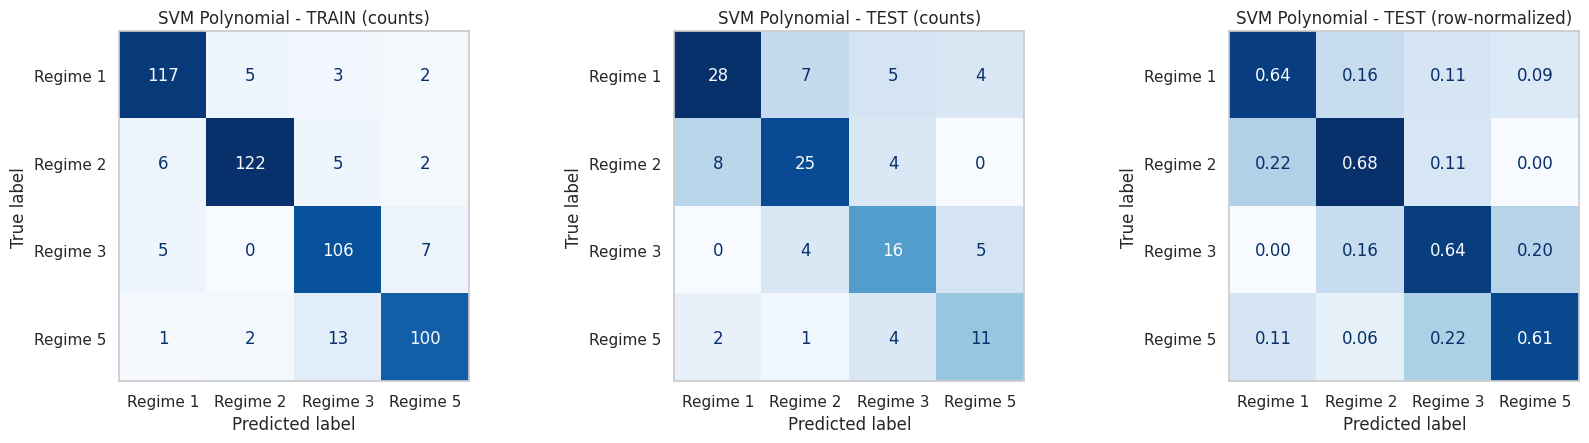

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

ConfusionMatrixDisplay.from_predictions(y_train, poly_train_pred, labels=class_labels, display_labels=class_names,
                                        cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("SVM Polynomial - TRAIN (counts)")

ConfusionMatrixDisplay.from_predictions(y_test, poly_test_pred, labels=class_labels, display_labels=class_names,
                                        cmap="Blues", ax=axes[1], colorbar=False)
axes[1].set_title("SVM Polynomial - TEST (counts)")

ConfusionMatrixDisplay.from_predictions(y_test, poly_test_pred, labels=class_labels, display_labels=class_names,
                                        normalize="true", values_format=".2f", cmap="Blues", ax=axes[2], colorbar=False)
axes[2].set_title("SVM Polynomial - TEST (row-normalized)")

for ax in axes:
    ax.grid(False)
plt.tight_layout(); plt.show()

## 33. Classification Report — SVM Polynomial

The classification report lists precision, recall and F1 **for each regime separately**, plus the averages. `support` is the number of real sites of that regime in the data being evaluated.

In [36]:
print("=" * 70)
print("SVM Polynomial - classification report on the TRAINING set (optimistic)")
print("=" * 70)
print(classification_report(y_train, poly_train_pred, labels=class_labels, target_names=class_names, digits=3, zero_division=0))

print("=" * 70)
print("SVM Polynomial - classification report on the TEST set (honest estimate)")
print("=" * 70)
print(classification_report(y_test, poly_test_pred, labels=class_labels, target_names=class_names, digits=3, zero_division=0))

# Keep the numbers for the final summary
results["SVM Polynomial"] = {
    "Micro-F1 (= accuracy) TRAIN": poly_micro_train,
    "Micro-F1 CV (5-fold, train)": poly_micro_cv,
    "Micro-F1 TEST": poly_micro_test,
    "Macro precision TEST": poly_prec_test_macro,
    "Macro recall TEST": poly_rec_test_macro,
    "Macro F1 TEST": poly_f1_test_macro,
    "Weighted F1 TEST": poly_f1_test_wtd,
}

SVM Polynomial - classification report on the TRAINING set (optimistic)
              precision    recall  f1-score   support

    Regime 1      0.907     0.921     0.914       127
    Regime 2      0.946     0.904     0.924       135
    Regime 3      0.835     0.898     0.865       118
    Regime 5      0.901     0.862     0.881       116

    accuracy                          0.897       496
   macro avg      0.897     0.896     0.896       496
weighted avg      0.899     0.897     0.898       496

SVM Polynomial - classification report on the TEST set (honest estimate)
              precision    recall  f1-score   support

    Regime 1      0.737     0.636     0.683        44
    Regime 2      0.676     0.676     0.676        37
    Regime 3      0.552     0.640     0.593        25
    Regime 5      0.550     0.611     0.579        18

    accuracy                          0.645       124
   macro avg      0.629     0.641     0.633       124
weighted avg      0.654     0.645     0.

## 34. Compare RBF vs Polynomial

Now we put the two kernels side by side. Remember: the kernel was selected by **cross-validation on the training set**; the **test set** gives the independent, honest comparison.

,Default (untuned) CV micro-F1,Micro-F1 (= accuracy) TRAIN,"Micro-F1 CV (5-fold, train)",Micro-F1 TEST,Macro precision TEST,Macro recall TEST,Macro F1 TEST,Weighted F1 TEST
SVM RBF,0.647,0.903,0.679,0.661,0.643,0.658,0.648,0.663
SVM Polynomial,0.637,0.897,0.661,0.645,0.629,0.641,0.633,0.647


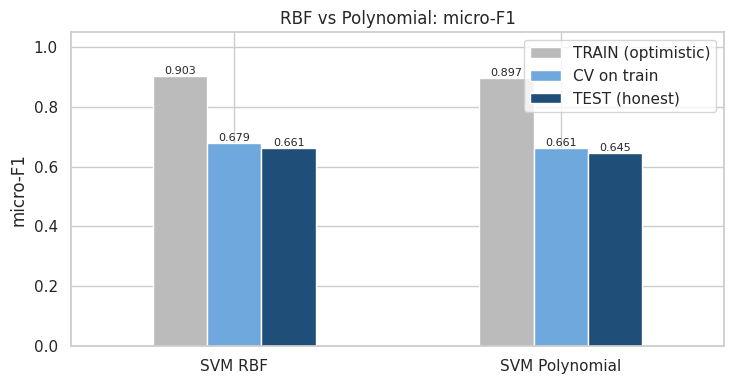

In [37]:
comparison = pd.DataFrame(results).T
comparison.insert(0, "Default (untuned) CV micro-F1", [rbf_default_cv.mean(), poly_default_cv.mean()])
display(comparison.round(3))

# Chart: micro-F1 for train / CV / test
plot_df = comparison[["Micro-F1 (= accuracy) TRAIN", "Micro-F1 CV (5-fold, train)", "Micro-F1 TEST"]]
plot_df.columns = ["TRAIN (optimistic)", "CV on train", "TEST (honest)"]
ax = plot_df.plot(kind="bar", figsize=(7.5, 4), rot=0, color=["#bbbbbb", "#6fa8dc", "#1f4e79"])
ax.set_ylabel("micro-F1"); ax.set_ylim(0, 1.05); ax.set_title("RBF vs Polynomial: micro-F1")
for cont in ax.containers: ax.bar_label(cont, fmt="%.3f", fontsize=8)
plt.tight_layout(); plt.show()

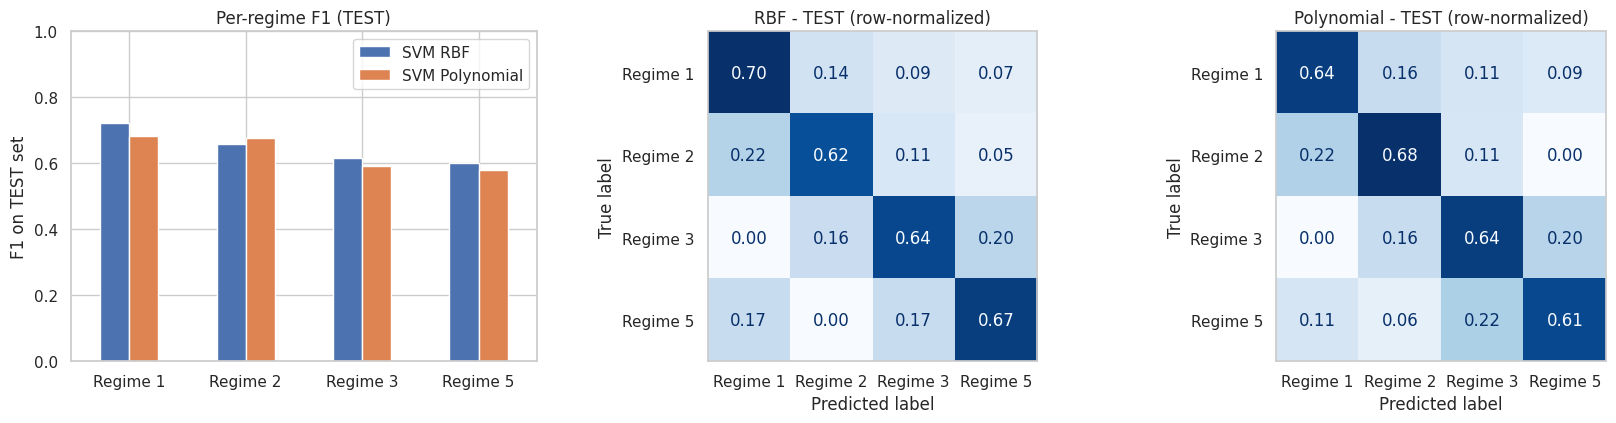

In [38]:
# Per-regime F1 on the TEST set, and the test confusion matrices side by side
f1_rbf  = f1_score(y_test, rbf_test_pred,  labels=class_labels, average=None, zero_division=0)
f1_poly = f1_score(y_test, poly_test_pred, labels=class_labels, average=None, zero_division=0)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.4))
pd.DataFrame({"SVM RBF": f1_rbf, "SVM Polynomial": f1_poly}, index=class_names).plot(kind="bar", ax=axes[0], rot=0)
axes[0].set_ylim(0, 1); axes[0].set_ylabel("F1 on TEST set"); axes[0].set_title("Per-regime F1 (TEST)")

ConfusionMatrixDisplay.from_predictions(y_test, rbf_test_pred, labels=class_labels, display_labels=class_names,
                                        normalize="true", values_format=".2f", cmap="Blues", ax=axes[1], colorbar=False)
axes[1].set_title("RBF - TEST (row-normalized)")
ConfusionMatrixDisplay.from_predictions(y_test, poly_test_pred, labels=class_labels, display_labels=class_names,
                                        normalize="true", values_format=".2f", cmap="Blues", ax=axes[2], colorbar=False)
axes[2].set_title("Polynomial - TEST (row-normalized)")
for ax in axes[1:]: ax.grid(False)
plt.tight_layout(); plt.show()

The summary below is generated from the numbers above, so it always matches the results.

In [39]:
r, p = results["SVM RBF"], results["SVM Polynomial"]
n_test = len(y_test)
diff_test = r["Micro-F1 TEST"] - p["Micro-F1 TEST"]
n_disagree = int((rbf_test_pred != poly_test_pred).sum())
se_r = np.sqrt(r["Micro-F1 TEST"] * (1 - r["Micro-F1 TEST"]) / n_test)
se_p = np.sqrt(p["Micro-F1 TEST"] * (1 - p["Micro-F1 TEST"]) / n_test)

better_cv   = "RBF" if r["Micro-F1 CV (5-fold, train)"] >= p["Micro-F1 CV (5-fold, train)"] else "Polynomial"
better_test = "RBF" if r["Micro-F1 TEST"] >= p["Micro-F1 TEST"] else "Polynomial"

print(f"Selection score (CV on train): RBF = {r['Micro-F1 CV (5-fold, train)']:.3f}   Polynomial = {p['Micro-F1 CV (5-fold, train)']:.3f}   -> higher: {better_cv}")
print(f"Honest score    (TEST)       : RBF = {r['Micro-F1 TEST']:.3f}   Polynomial = {p['Micro-F1 TEST']:.3f}   -> higher: {better_test}")
print(f"Overfitting (TRAIN - TEST)   : RBF = {r['Micro-F1 (= accuracy) TRAIN'] - r['Micro-F1 TEST']:+.3f}   Polynomial = {p['Micro-F1 (= accuracy) TRAIN'] - p['Micro-F1 TEST']:+.3f}")
print(f"The two models give different predictions for {n_disagree} of {n_test} test sites.")
print(f"Test difference = {abs(diff_test):.3f} = {int(round(abs(diff_test) * n_test))} site(s). Each model's test score has a standard error of about {se_r:.3f} / {se_p:.3f}.")
if abs(diff_test) < 2 * max(se_r, se_p):
    print("-> The difference is small compared with this uncertainty, so we should NOT claim that one kernel is clearly better on this test set.")
else:
    print("-> The difference is large compared with the uncertainty; the better kernel is likely genuinely better here.")

gap_r = r["Micro-F1 (= accuracy) TRAIN"] - r["Micro-F1 TEST"]
gap_p = p["Micro-F1 (= accuracy) TRAIN"] - p["Micro-F1 TEST"]
if min(gap_r, gap_p) > 0.10:
    print("-> Both kernels score much higher on the TRAINING sites than on the TEST sites (gap > 0.10): flexible SVMs partly MEMORIZE "
          "the training sites. The training score must NOT be reported as the model's performance - use the TEST (and CV) scores.")

Selection score (CV on train): RBF = 0.679   Polynomial = 0.661   -> higher: RBF
Honest score    (TEST)       : RBF = 0.661   Polynomial = 0.645   -> higher: RBF
Overfitting (TRAIN - TEST)   : RBF = +0.242   Polynomial = +0.252
The two models give different predictions for 11 of 124 test sites.
Test difference = 0.016 = 2 site(s). Each model's test score has a standard error of about 0.043 / 0.043.
-> The difference is small compared with this uncertainty, so we should NOT claim that one kernel is clearly better on this test set.
-> Both kernels score much higher on the TRAINING sites than on the TEST sites (gap > 0.10): flexible SVMs partly MEMORIZE the training sites. The training score must NOT be reported as the model's performance - use the TEST (and CV) scores.


## 35. Final Conclusion

In [40]:
print("=" * 72)
print("FINAL SUMMARY - SVM (all numbers computed above)")
print("=" * 72)
print(f"Data           : {len(X)} sites, {X.shape[1]} features, classes {class_labels}")
print(f"Split          : {len(X_train)} train / {len(X_test)} test (random_state={SPLIT_RANDOM_STATE})")
print(f"Preprocessing  : median imputation + standardization, fitted on training data only (Pipeline)")
print(f"RBF kernel     : best settings {rbf_search.best_params_}")
print(f"Poly kernel    : best settings {poly_search.best_params_}")
print()
display(pd.DataFrame(results).T.round(3))
print(f"\nHEADLINE (main metric)  TEST micro-average F1:  RBF = {results['SVM RBF']['Micro-F1 TEST']:.3f}   |   Polynomial = {results['SVM Polynomial']['Micro-F1 TEST']:.3f}")

FINAL SUMMARY - SVM (all numbers computed above)
Data           : 620 sites, 20 features, classes [1, 2, 3, 5]
Split          : 496 train / 124 test (random_state=47)
Preprocessing  : median imputation + standardization, fitted on training data only (Pipeline)
RBF kernel     : best settings {'model__C': 10, 'model__gamma': 0.05}
Poly kernel    : best settings {'model__C': 100, 'model__coef0': 1, 'model__degree': 3, 'model__gamma': 0.01}



,Micro-F1 (= accuracy) TRAIN,"Micro-F1 CV (5-fold, train)",Micro-F1 TEST,Macro precision TEST,Macro recall TEST,Macro F1 TEST,Weighted F1 TEST
SVM RBF,0.903,0.679,0.661,0.643,0.658,0.648,0.663
SVM Polynomial,0.897,0.661,0.645,0.629,0.641,0.633,0.647



HEADLINE (main metric)  TEST micro-average F1:  RBF = 0.661   |   Polynomial = 0.645


### What we did
We trained two **Support Vector Machines** to predict four coral reef regimes from 20 human and natural predictors: one with an **RBF kernel** and one with a **polynomial kernel**. Missing `Complexity`/`Depth` values were filled with training-data medians and **all features were standardized** (essential for SVMs). The settings of each kernel were chosen by 5-fold cross-validation on the training set only, using micro-average F1. All preprocessing sits inside a `Pipeline`, so no test-set information reached the models. Each final model was evaluated once on the held-out test set with micro-average F1 as the main metric, supported by accuracy, precision, recall, macro/weighted F1, confusion matrices and per-regime reports.

### What the results tell us
Use the **comparison tables and the generated summary in section 34**: Which kernel scores higher in cross-validation and on the test set? Does either show a large TRAIN–TEST gap (overfitting)? Does tuning beat the untuned defaults the reference used? Which regimes are hardest for both? If the two kernels end up within the uncertainty of a small test set, the honest conclusion is that they perform similarly.

**General expectations (to check against our numbers, not to be assumed):** the RBF kernel is a flexible, general-purpose choice with only two settings to tune; the polynomial kernel has more settings (so more risk of over-tuning on a small dataset) and can become unstable at high degree.

### Limitations
* **Small data:** a few hundred sites; the test set is small, so scores carry noticeable uncertainty.
* **Imputation:** a constant fill for `Complexity` (missing for roughly a fifth of sites) reduces that feature's usefulness.
* **Black-box models:** unlike logistic regression, kernel SVMs do not give simple per-feature coefficients, so they are harder to interpret.
* **Spatial dependence:** nearby sites are similar, so a random split may be slightly optimistic about performance in a new area.
* **Limited tuning grids:** we searched small grids to keep the notebook fast and readable; wider searches could change the chosen settings.

### Why our results may differ from the reference project's results

It is perfectly fine (and expected) if our numbers differ. Possible reasons:

1. **Different missing-value handling.** The reference's final data file filled `Complexity` with a Lasso model trained on all sites *before* splitting (leakage); we use a training-only median inside the pipeline.
2. **Different thing being reported.** The reference's results table mainly shows *cross-validation* scores on the training + validation data. Our headline number is the score on a *held-out test set*.
3. **Their "micro-average F1" helper function actually computes the *weighted* average F1** (it reads the `weighted avg` line of the classification report). We compute the true micro-average F1 (which, for single-label multi-class problems, equals accuracy) and also report the weighted F1 separately.
4. **Hyper-parameter tuning.** We tune settings with cross-validation and scikit-learn today uses different defaults (and different optimizers) than the old scikit-learn version the reference used (for example, the SVM `gamma` default changed).
5. **Random splits and a small dataset.** With only a few hundred sites, a handful of sites can change a score by several percentage points. Different random seeds for cross-validation or a different split give different numbers.
6. **Spatial dependence.** Neighbouring reef sites often share almost identical environmental values (several predictors are the same for nearby sites). A random split can therefore place near-duplicates in both train and test sets, which can make results look slightly better than they would on a truly new region.
7. **Software versions.** Different scikit-learn / NumPy versions can change numerical details.